# Akkuvaraston ajojärjestyksen optimointi energia-arbitraasille ja huippujen leikkaamiselle

## Yhteenveto johdolle

Verkkoon kytketty kaupallinen kohde käyttää 2 MW / 8 MWh:n litiumioniakkua mitatun sähkökuorman rinnalla. Kohteelle laskutetaan kahdella tavalla: tuntikohtaisella vuorokausimarkkinan **energiahinnalla** ($/MWh) ja kuukausittaisella **tehomaksulla**, joka perustuu sen korkeimpaan verkosta oton yksittäiseen jaksoon ($/MW). Omaisuudenhoitajan on päätettävä tunti tunnilta, milloin akkua ladataan (ostetaan halpaa energiaa ja nostetaan verkosta ottoa) ja milloin se puretaan (kompensoidaan kallista energiaa ja lasketaan verkosta ottoa). Kaksi arvovirtaa kilpailee keskenään: **energia-arbitraasi** (osta halvalla yöllä, pura iltahuipun aikaan) ja **huippujen leikkaaminen** (rajoita laskutettua verkkomaksimia). Lataaminen ei ole ilmaista — edestakaisen hyötysuhteen vuoksi noin 10 % varastoidusta energiasta menetetään — joten aikataulu on aito optimointi, ei heuristiikka.

Tämä muistikirja rakentaa päätöksen alusta loppuun. Se ensin syntetisoi realistisen 24 tunnin vuorokausimarkkinan hintakäyrän (aamu- ja iltahuipuilla sekä yöllisellä pohjalla) ja korreloidun kohteen kuormaprofiilin, minkä jälkeen se profiloi molemmat **PROC MEANS** -proseduurilla ja robustilla **PROC UNIVARIATE** 2,5/97,5-persentiilin hintakaistalla. Ytimen muodostaa lineaarinen ohjelma **PROC OPTMODEL** -proseduurissa: päätösmuuttujat tuntikohtaiselle lataukselle, purulle ja varaustilalle, sekä laskutetun huipun muuttuja, joita rajoittavat kumulatiivinen varaustilan tase (erillisellä lataus-/purkuhyötysuhteella), teho- ja kapasiteettirajat sekä huipun määrittelyrajoite. Tavoitefunktio maksimoi arbitraasimarginaalin tehomaksulla vähennettynä. **PROC SQL** kvantifioi sitten perustason ja optimoidun kustannuksen, ja kolme **PROC SGPLOT** -paneelia visualisoivat lataus-/purkuaikataulun hintaa vasten, varaustilan kehityskulun ja tasoitetun verkosta oton profiilin.

**Tulos synteettiselle päivälle:** optimoija täyttää akun halvimpien yötuntien aikana, purkaa sekä aamu- että iltahintahuippuihin, lataa uudelleen keskipäivän hintanotkon läpi ja — ratkaisevaa kyllä — pidättelee latausteoaan niin, ettei se koskaan luo uutta verkkohuippua. Päivittäinen energiakustannus laskee arvosta **\$2 903,78 arvoon \$2 528,43** — **\$375,34 (12,9 %) arbitraasisäästöä** — samalla kun laskutettu verkkomaksimi laskee arvosta **3,59 MW arvoon 3,43 MW** (noin **0,16 MW**), mikä on lisäksi **\$18,98** arvoinen oletetulla päiväkohtaisella tehomaksuosuudella. Sama malli skaalautuu pidemmille aikahorisonteille, useille hintaskenaarioille tai degradaatiotietoiselle sykkimiselle yksinkertaisesti laajentamalla indeksijoukkoa ja rajoitteita.

## Datalähteet

Kaikki data on **synteettistä**, ja se generoidaan sisäisesti ensimmäisessä koodisolussa komennolla `CALL STREAMINIT(20260605)` toistettavuuden vuoksi. Ei ulkoisia tiedostoja eikä verkkoyhteyttä. Yksi datajoukko, `price_load`, jossa on 24 tuntiriviä yhtä käyttöpäivää edustaen.

| Muuttuja | Tyyppi | Yksiköt | Kuvaus |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Käyttöpäivän tunti (aikahorisontin indeksi) |
| `price` | num | $/MWh | Vuorokausimarkkinan energiahinta: yöllinen pohja, aamu- + iltahuiput, Gaussin kohinalla (lattia $5) |
| `load` | num | MW | Kohteen sähkönkysyntä, korreloitu päivittäisen toiminnan kanssa (lattia 0,3 MW) |
| `day_type` | char | — | Tariffi-ikkunan lippu: `PeakTOU` (tunnit 17–21) vs. `OffPeak`, käytetään huippu-/ei-huippuhintaeron yhteenvedossa |

Akun parametrit ovat kiinteitä mallin vakioita PROC OPTMODEL -proseduurin sisällä: 8 MWh käytettävissä olevaa kapasiteettia, 2 MW maksimilataus-/purkuteho, 0,95 lataus- ja 0,95 purkuhyötysuhde (~90 % edestakainen), aloitusvaraustila 0 MWh, ja \$120/MW tehomaksu, joka kohdistetaan päivän laskutettuun verkkohuippuun (kuukausittaisen tehomaksun päiväkohtaisesti jaksotettu osuus).

# Akkuvaraston ajojärjestyksen optimointi
## Energia-arbitraasi ja huippujen leikkaaminen verkkoon kytketylle kohteelle

Kaupallinen kohde käyttää **2 MW / 8 MWh:n akkua** mittarinsa takana. Sen sähkölaskussa on kaksi osaa: tuntikohtainen **energiahinta** ($/MWh) ja kuukausittainen **tehomaksu**, joka perustuu korkeimpaan verkosta oton yksittäiseen jaksoon ($/MW). Käyttäjä haluaa tuntikohtaisen lataus-/purkuaikataulun, joka nappaa kaksi arvovirtaa kerralla:

- **Arbitraasi** — varastoi halpaa yöenergiaa, vapauta se kalliiden huipputuntien aikana.
- **Huippujen leikkaaminen** — pura kysyntäpiikin aikana laskutetun verkkomaksimin laskemiseksi.

Koska edestakainen hyötysuhde menettää ~10 % varastoidusta energiasta, kompromissi ei ole triviaali ja edellyttää aitoa optimointia. Muotoilemme sen lineaarisena ohjelmana **PROC OPTMODEL** -proseduurissa, minkä jälkeen kvantifioimme ja visualisoimme tuloksen.

> Kaikki alla oleva data on synteettistä ja generoitu sisäisesti — muistikirja on täysin itsenäinen ja suoriutuu muutamassa sekunnissa.

## 1. Generoi synteettinen vuorokausimarkkinan hinta- ja kuormaprofiili

Rakennamme yhden käyttöpäivän (24 tuntiriviä). Hintakäyrällä on yöllinen pohja sekä aamu- + iltahuiput; kohteen kuorma on korreloitu päivittäisen toiminnan kanssa. Kiinteä siemen pitää ajon toistettavana. Merkitsemme myös lakisääteisen käyttöajan (time-of-use) huippuikkunan, jotta voimme myöhemmin tehdä yhteenvedon huippu-/ei-huippuerosta.

In [1]:
TIEDOT price_load;
    CALL streaminit(20260605);
    PITUUS day_type $9;
    TEE hour = 0 ASTI 23;
        /* Diurnal energy price ($/MWh): morning + evening peaks */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        JOS price < 5 NIIN price = 5;

        /* Site load (MW): overnight trough, evening ramp */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        JOS LOAD < 0.3 NIIN LOAD = 0.3;

        JOS hour >= 17 AND hour <= 21 NIIN day_type = 'Huippu';
        MUUTEN day_type = 'Ei-huippu';
        TULOSTE;
    LOPPU;
    POISTA BASE;
SUORITA;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profiloi hinta- ja kuormajakaumat

Ennen optimointia tarkistamme syötteiden järkevyyden. Halvimman ja kalleimman tunnin välinen ero on se, minkä arbitraasi rahaksi muuttaa, ja maksimikuorma ankkuroi huippujen leikkaamisen mahdollisuuden.

In [2]:
PROSEDUURI KESKIARVOT TIEDOT=price_load n mean std MIN MAX maxdec=2;
    MUUTTUJA price LOAD;
    NIMIKE price="Sähkön hinta ($/MWh)" LOAD="Kohteen kuorma (MW)";
    OTSIKKO "Hinta- ja kuormajakaumat";
SUORITA;


                                                Hinta- ja kuormajakaumat                                                

                                                  The MEANS Procedure

 Variable  Label                         N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------------------------------
 price     Sähkön hinta ($/MWh)         24       46.29       15.81       18.57       79.27
 LOAD      Kohteen kuorma (MW)          24        2.47        0.48        1.71        3.59
 -----------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Huippu- vs. ei-huippuhinnan ero

Käyttöaikalipun mukaan ryhmittely osoittaa, kuinka paljon rikkaampia huipputunnit ovat ei-huipun perustasoon verrattuna — rakenteellinen signaali, jota akku hyödyntää.

In [3]:
PROSEDUURI KESKIARVOT TIEDOT=price_load mean MIN MAX maxdec=2;
    LUOKKA day_type;
    MUUTTUJA price;
    NIMIKE day_type="Käyttöaikaluokka" price="Sähkön hinta ($/MWh)";
    OTSIKKO "Huippu- vs. ei-huippuhinnat";
SUORITA;


                                              Huippu- vs. ei-huippuhinnat                                               

                                                  The MEANS Procedure

                                   Analysis Variable : price Sähkön hinta ($/MWh)

                                                     N
                             Käyttöaikaluokka      Obs       Mean      Minimum      Maximum
                             --------------------------------------------------------------
                             Ei-huippu              19      40.46        18.57        54.89
                             Huippu                  5      68.45        54.88        79.27
                             --------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Robusti hintakaista (2,5 / 97,5 -persentiilit)

Kuvaamme hinnan hännät 2,5 / 97,5 -persentiilin kaistalla. **PROC UNIVARIATE** `PCTLPTS=`-optiolla laskee mielivaltaiset persentiilit siististi, mikä on oikea työkalu murtolukupersentiileille.

In [4]:
PROSEDUURI UNIVARIATE TIEDOT=price_load NOPRINT;
    MUUTTUJA price;
    TULOSTE out=price_band pctlpts=2.5 97.5 pctlpre=p_;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=price_band noobs;
    OTSIKKO "Robusti hintakaista (2,5 / 97,5 -persentiilit)";
SUORITA;


                                     Robusti hintakaista (2,5 / 97,5 -persentiilit)                                     

P_2_5  P_97_5
18.57   79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. Ajojärjestyksen optimointi (lineaarinen ohjelma)

Luemme tuntikohtaisen hinnan ja kuorman PROC OPTMODEL -proseduuriin ja määrittelemme:

- `chg[h]`, `dis[h]` — tuntikohtainen lataus-/purkuteho (MW), rajattuna 2 MW:n invertteriteholla.
- `soc[h]` — varaustila (MWh), rajattuna 8 MWh:n käytettävissä olevalla kapasiteetilla.
- `peak` — laskutettu verkkomaksimi (MW).

**Rajoitteet.** `soc_balance` kumuloi nettoenergian jokaisen tunnin läpi erillisellä lataus-/purkuhyötysuhteella (tuntikohtaisen rekursion juokseva summa -muoto). `peak_def` pakottaa `peak`-muuttujan hallitsemaan jokaisen tunnin verkosta ottoa, joten sen minimointi leikkaa tehomaksua.

**Tavoitefunktio.** Maksimoi arbitraasimarginaali — `price × (discharge − charge)` päivän yli summattuna — miinus laskutetun huipun tehomaksu. Ratkaisemme sen jatkuvana LP:nä.

In [5]:
PROSEDUURI optmodel;
    ASETA HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ TIEDOT price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Battery: 8 MWh usable, 2 MW power, ~90% round-trip efficiency */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Demand charge applied to this day's billed grid peak ($/MW).
       Commercial demand charges are monthly; 120 is the marginal value of
       shaving today's grid maximum once the monthly charge is amortized to
       the day. It is large enough that the optimizer will hold charging
       power back rather than create a new, higher peak. */
    num demand_chg = 120;

    /* Decision variables (MW charge / discharge, MWh state of charge) */
    MUUTTUJA chg{HOURS}  >= 0 <= p_max;
    MUUTTUJA dis{HOURS}  >= 0 <= p_max;
    MUUTTUJA soc{HOURS}  >= 0 <= capacity;
    MUUTTUJA peak        >= 0;   /* billed grid peak (MW) for demand charge */

    /* Net grid import after battery action (MW) */
    impvar grid_mw{h SISÄLLÄ HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Cumulative state of charge: energy in less energy out through hour h,
       with charge/discharge efficiency applied. Equivalent to an hourly
       recurrence but stated as a running sum over prior hours. */
    con soc_balance{h SISÄLLÄ HOURS}:
        soc[h] = soc0
                 + sum{k SISÄLLÄ HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Peak shaving: billed peak is the max grid import across the day */
    con peak_def{h SISÄLLÄ HOURS}: peak >= grid_mw[h];

    /* Maximize energy-arbitrage margin net of the peak demand charge */
    MAX net_value =
        sum{h SISÄLLÄ HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE TIEDOT dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;

                                     Robusti hintakaista (2,5 / 97,5 -persentiilit)                                     


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Optimaalinen tuntikohtainen aikataulu

Ratkaistu taulukko näyttää latauksen jakautuneena halpojen yö- ja keskipäivätuntien kesken — maltillistettuna noin 1,0–1,7 MW:iin, jottei se koskaan aseta uutta verkkohuippua — purun keskittyneenä aamu- ja iltahintahuippuihin, ja varaustilan piirtämässä järkevän täytä-ja-vapauta-syklin 8 MWh:n katon sisällä. `grid_mw`-sarake pitää tasaisen ~3,43 MW:n katon jokaisen laustuntisen läpi, mikä on sitovan huipporajoitteen tunnusmerkki.

In [6]:
PROSEDUURI TULOSTA TIEDOT=dispatch noobs NIMIKE;
    MUUTTUJA hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    NIMIKE hour="Vuorokauden tunti" price="Sähkön hinta ($/MWh)"
          LOAD="Kohteen kuorma (MW)" charge_mw="Latausteho (MW)"
          discharge_mw="Purkuteho (MW)" soc_mwh="Varaustila (MWh)"
          grid_mw="Verkkotuonti (MW)";
    OTSIKKO "Optimaalinen tuntiaikataulu";
SUORITA;


                                              Optimaalinen tuntiaikataulu                                               

Vuorokauden tunti    Sähkön hinta ($/MWh)  Kohteen kuorma (MW)  Latausteho (MW)  Purkuteho (MW)  Varaustila (MWh)  Verkkotuonti (MW)
                0                   29.73                 1.99        1.4418421               0           1.36975          3.4318421
                1                   28.03                 2.16        1.2718421               0             2.578          3.4318421
                2                   21.87                    2        1.4318421               0           3.93825          3.4318421
                3                   18.57                 1.71        1.7218421               0             5.574          3.4318421
                4                   27.62                 2.13        1.3018421               0           6.81075          3.4318421
                5                   36.12                 2.18        1.2518421 


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Otsikkotason KPI:t: perustaso vs. optimoitu

Vertaamme älä-tee-mitään-perustasoa (maksa raakakuorman hinta joka tunti) optimoituun verkkoasemaan ja raportoimme arbitraasisäästöt, laskutetun huipun vähennyksen ja tuon vähennyksen rahallisen arvon tehomaksulla — kaksi vipua, jotka ohjaavat liiketoimintaperusteita.

In [7]:
PROSEDUURI SQL;
    CREATE TABLE kpi AS
    VALITSE
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

PROSEDUURI TULOSTA TIEDOT=kpi noobs NIMIKE;
    NIMIKE base_energy_cost="Perusenergian kustannus"
          opt_energy_cost="Optimoitu energiakustannus"
          arbitrage_savings="Arbitraasisäästö"
          base_peak_mw="Perushuippu (MW)"
          opt_peak_mw="Optimoitu huippu (MW)"
          peak_reduction_mw="Huipun lasku (MW)"
          demand_charge_savings="Tehomaksusäästö";
    OTSIKKO "Keskeiset tunnusluvut: perus vs. optimoitu";
SUORITA;


                                              Optimaalinen tuntiaikataulu                                               

                                       Keskeiset tunnusluvut: perus vs. optimoitu                                       

Perusenergian kustannus  Optimoitu energiakustannus     Arbitraasisäästö  Perushuippu (MW)  Optimoitu huippu (MW)  Huipun lasku (MW)     Tehomaksusäästö
              2903.7774             2528.4335145526       375.3438854474              3.59              3.4318421          0.1581579           18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Lataus-/purkuaikataulu hintaa vasten

Lataus (siniset neulat) ja purku (punainen viiva merkeillä) jakavat vasemman megawattiakselin; vuorokausimarkkinan hinta (vihreä katkoviiva) luetaan oikealta. Lataus keskittyy halpoihin yö- ja keskipäivätunteihin, kun taas purku laukeaa aamu- ja iltahintahuippuihin — visualisointi vahvistaa, että optimoija ostaa halvalla ja myy kalliilla.

                                       Keskeiset tunnusluvut: perus vs. optimoitu                                       




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


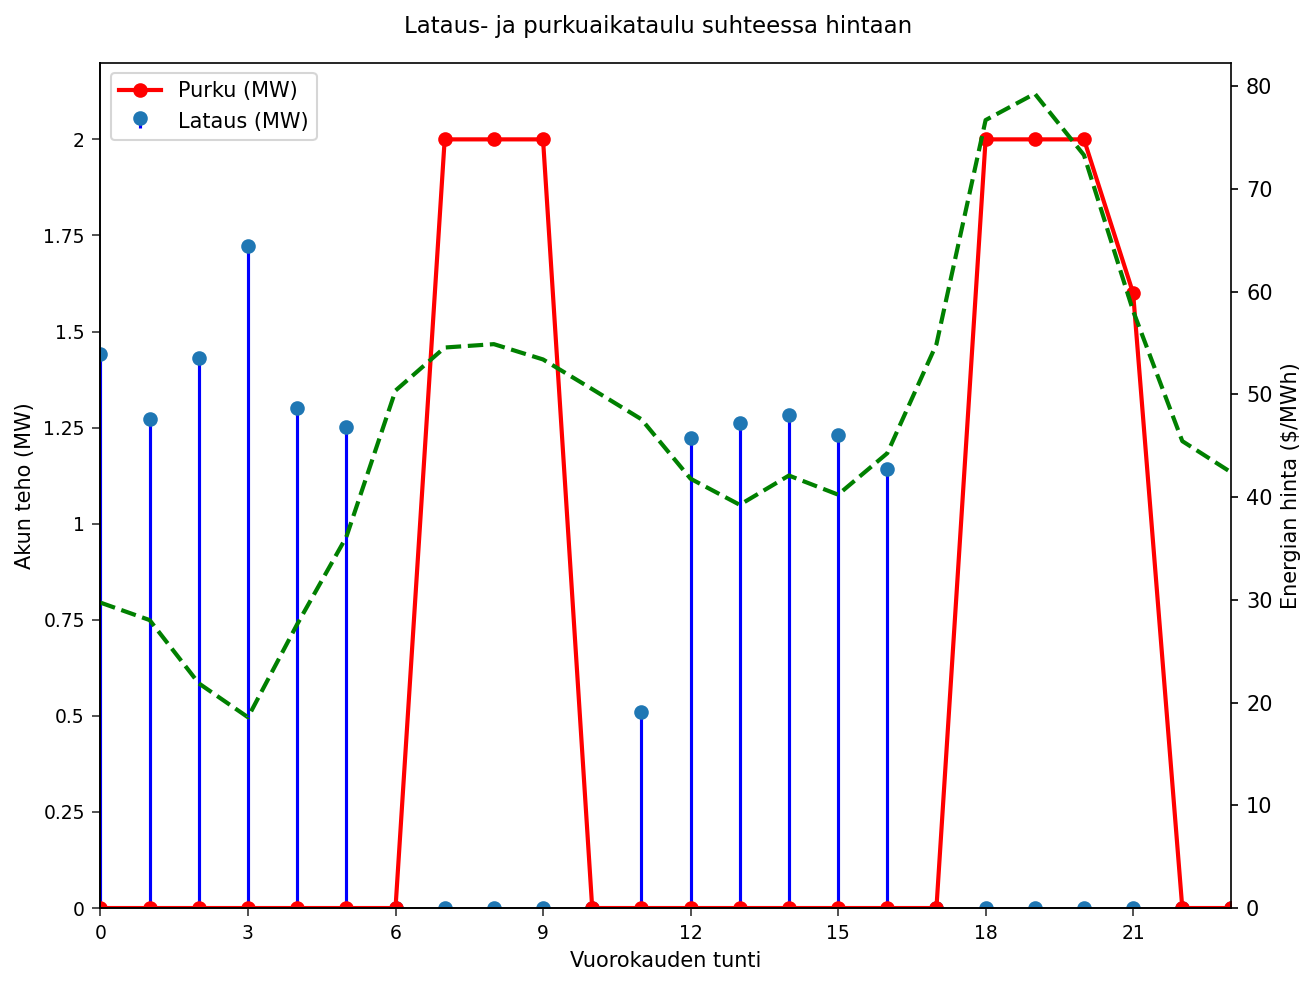

In [8]:
PROSEDUURI SGPLOT TIEDOT=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Lataus (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Purku (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Hinta ($/MWh)";
    XAXIS NIMIKE="Vuorokauden tunti" VALUES=(0 ASTI 23 MUKAAN 3);
    YAXIS NIMIKE="Akun teho (MW)" MIN=0 MAX=2.2;
    y2axis NIMIKE="Energian hinta ($/MWh)" MIN=0;
    OTSIKKO "Lataus- ja purkuaikataulu suhteessa hintaan";
SUORITA;


## 9. Varaustilan kehityskulku

Varastoitu energia nousee akun täyttyessä yöllä, laskee jokaisen purkuikkunan läpi eikä koskaan riko 8 MWh:n käytettävissä olevan kapasiteetin kattoa (pisteviitteinen viiterivi).

                                       Keskeiset tunnusluvut: perus vs. optimoitu                                       




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


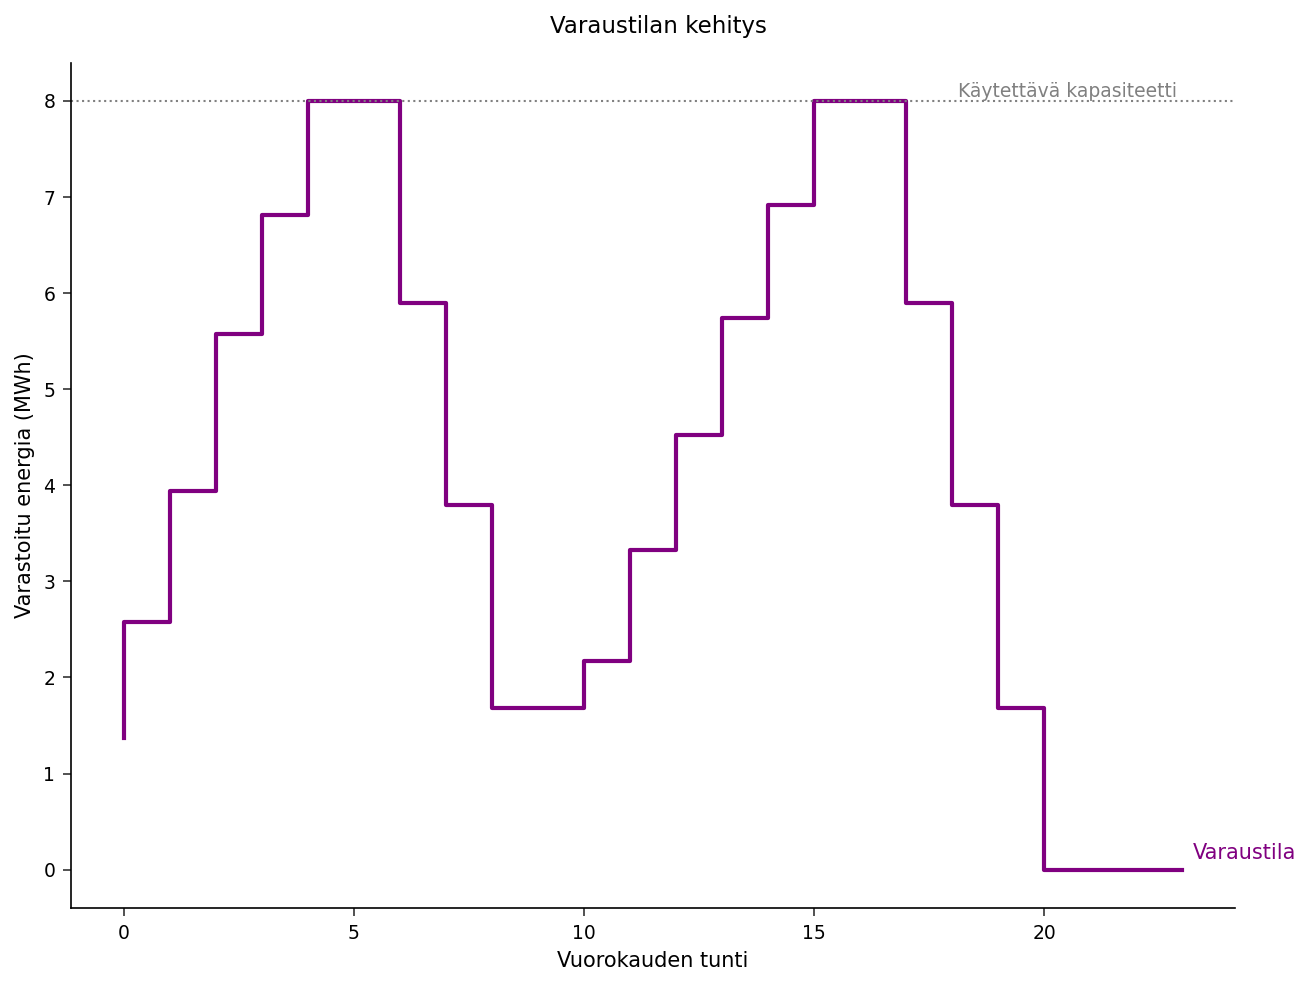

In [9]:
PROSEDUURI SGPLOT TIEDOT=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Varaustila";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        NIMIKE="Käytettävä kapasiteetti";
    XAXIS NIMIKE="Vuorokauden tunti";
    YAXIS NIMIKE="Varastoitu energia (MWh)";
    OTSIKKO "Varaustilan kehitys";
SUORITA;


## 10. Verkosta otto: ennen vs. jälkeen ajojärjestyksen

Oranssi viiva (verkosta otto akun kanssa) laskee selvästi katkoviivaisen perustason kuorman alle iltarampin (tunnit 18–21) läpi — huippujen leikkausvaikutus, joka laskee tehomaksua. Yön ja keskipäivän latausikkunoiden aikana se nousee, mutta optimoija rajaa sen tasaiseen ~3,43 MW:n kattoon, joka pysyy *alle* alkuperäisen 3,59 MW:n kuormahuipun, joten lataus ostaa halpaa energiaa asettamatta uutta laskutettua maksimia.

                                       Keskeiset tunnusluvut: perus vs. optimoitu                                       




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


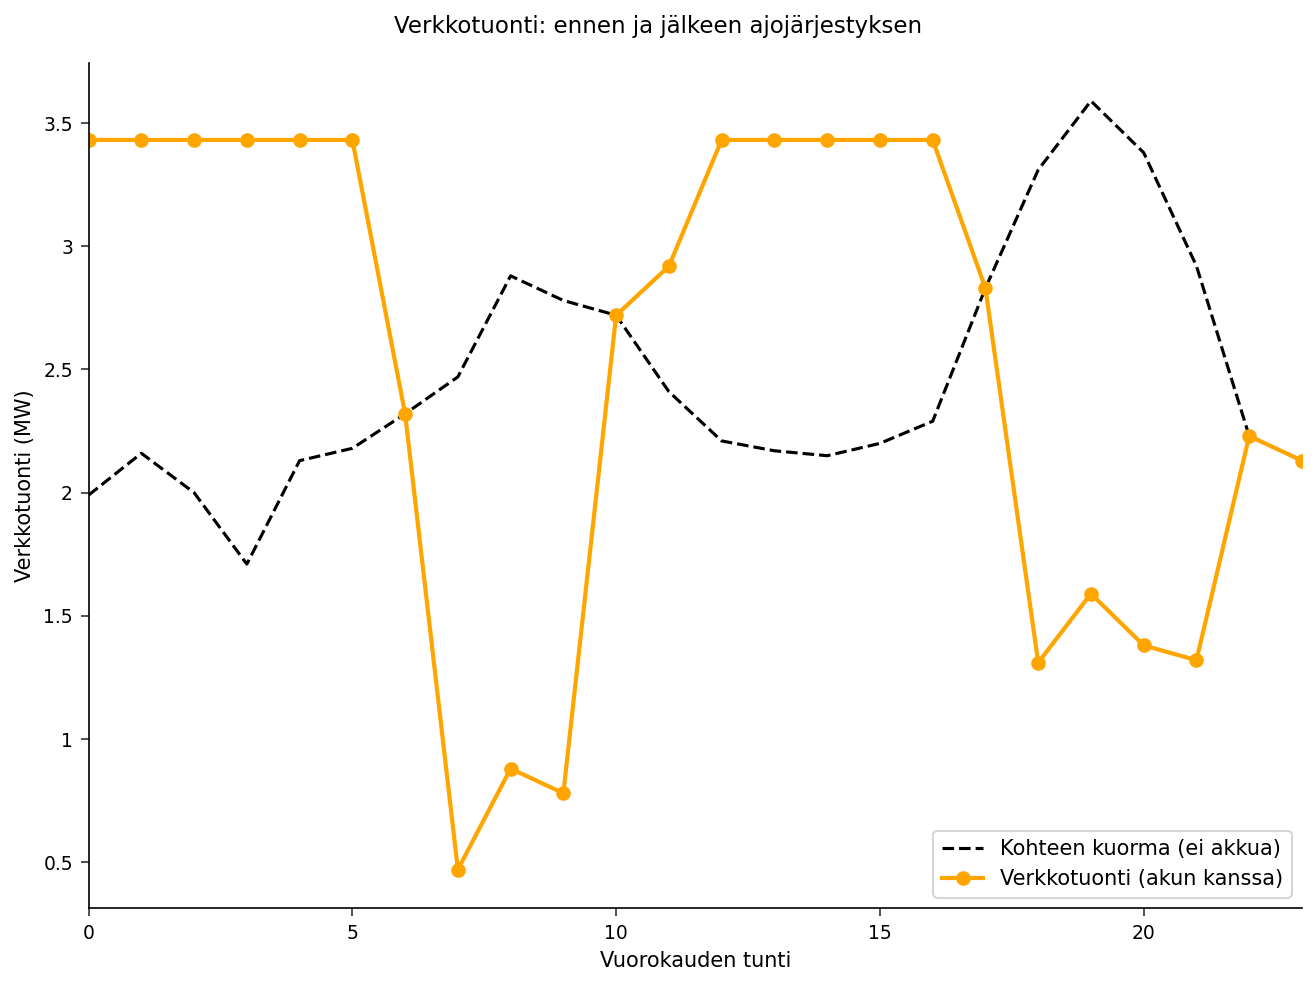

In [10]:
PROSEDUURI SGPLOT TIEDOT=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Kohteen kuorma (ei akkua)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Verkkotuonti (akun kanssa)";
    XAXIS NIMIKE="Vuorokauden tunti";
    YAXIS NIMIKE="Verkkotuonti (MW)";
    OTSIKKO "Verkkotuonti: ennen ja jälkeen ajojärjestyksen";
SUORITA;


## Tulkinta ja jatkotoimet

**Mitä malli päätti.** Vaikka edestakainen hyötysuhde verottaa jokaista sykliä, optimoija löysi silti selvää arvoa: se täytti akun halvimpien yötuntien aikana, purki aamuhintahuippuun (tunnit 7–9), latasi uudelleen keskipäivän hintanotkon läpi (tunnit 11–16) ja purki jälleen rikkaimpaan iltahuippuun (tunnit 18–21). Kuvaavasti se latasi vain 1,0–1,7 MW:n teholla täyden 2 MW:n nimellistehon sijaan yöllisen täytön aikana — pidätellen tehoa niin, ettei lisätty verkosta otto koskaan työntänyt ottoa päivän kuormahuipun yläpuolelle. Varaustila kunnioitti sekä 8 MWh:n kapasiteettia että 2 MW:n tehorajaa kaikkina aikoina.

**Liiketoimintaperusteet.** Päivittäinen energiakustannus laski arvosta **\$2 903,78 arvoon \$2 528,43** — **\$375,34 (12,9 %)** arbitraasisäästöä — ja laskutettu verkkomaksimi laski arvosta **3,59 MW arvoon 3,43 MW** (noin **0,16 MW**), leikaten lisäksi **\$18,98** tehomaksuriviltä. Vuositasolle laskettuna käyttöpäivien yli plus toistuva tehomaksun vähennys, tämä on sellaista marginaalia, joka rahoittaa varastointi-investoinnin.

**Miksi LP on oikea työkalu.** Heuristiikat ("lataa mediaanihinnan alle, pura sen yli") sivuuttavat hyötysuhdehäviöt, kapasiteetin kytkeytymisen tuntien välillä ja sen tosiasian, että tehomaksu riippuu yhdestä ainoasta jaksosta — ne lataisivat täydellä teholla yöllä ja *nostaisivat* laskutettua huippua, tuhoten huippujen leikkaamisen arvon. PROC OPTMODEL nappaa kaikki nämä yhteen deklaratiiviseen malliin ja palauttaa todistettavasti optimaalisen aikataulun, joka tässä tarkoituksellisesti maltillistaa latausnopeutta huipun suojaamiseksi.

**Mallin laajentaminen.**

- **Pidemmät aikahorisontit / monipäiväiset** — laajenna `HOURS`-indeksijoukkoa; lisää päivienväliset sykkimisrajat.
- **Hintaepävarmuus** — ratkaise LP useiden hintaskenaarioiden yli ja keskiarvoista ensimmäisen tunnin päätös (rullaava stokastinen politiikka).
- **Akun degradaatio** — lisää läpimenon rangaistustermi tai kumulatiivisten syklien rajoite arbitraasin ja omaisuuden käyttöiän tasapainottamiseksi.
- **Taajuusvaste / kapasiteettimarkkinat** — ota käyttöön varatun pelivaran rajoitteet, jotta akku voi pinota lisäpalvelutuloja arbitraasin päälle.

Kaikki nämä ovat inkrementaalisia muokkauksia samaan OPTMODEL-lohkoon — tässä luotu rakenne kantaa muuttumattomana läpi.